# Module 1: Wrangle data

>[!NOTE]
> These links are not real. This the the claude-generated tutorial showing how public data can be wrangled from the internet.

In [1]:
import urllib.request
import os

os.makedirs("data", exist_ok=True)

files = {
    "promoters.fa": "https://raw.githubusercontent.com/kieranrcampbell/genomics-ml-tutorial/main/data/promoters.fa",
    "expression.tsv": "https://raw.githubusercontent.com/kieranrcampbell/genomics-ml-tutorial/main/data/expression.tsv"
}

for filename, url in files.items():
    path = f"data/{filename}"
    if not os.path.exists(path):
        print(f"Downloading {filename}...")
        urllib.request.urlretrieve(url, path)
        print(f"  Saved to {path}")
    else:
        print(f"  {filename} already exists, skipping.")

  promoters.fa already exists, skipping.
  expression.tsv already exists, skipping.


### Generate some synthetic training data

In [2]:
import numpy as np
import pandas as pd
from Bio.Seq import Seq
import os

os.makedirs("data", exist_ok=True)
rng = np.random.default_rng(seed=42)

# --- Biological parameters ---
N_GENES = 1000
PROMOTER_LENGTH = 200  # shortened for speed; real promoters ~1000bp

# Two real yeast transcription factor binding motifs
# TATA box (associated with high expression in many genes)
TATA_BOX = "TATAAA"
# Poly-A stretch (associated with nucleosome positioning)
POLYA = "AAAAAA"

BASES = ['A', 'T', 'G', 'C']

def random_sequence(length, rng, gc_content=0.38):
    """Generate a random DNA sequence with specified GC content."""
    at = (1 - gc_content) / 2
    gc = gc_content / 2
    probs = [at, at, gc, gc]  # A, T, G, C
    return ''.join(rng.choice(BASES, size=length, p=probs))

def insert_motif(seq, motif, position):
    """Insert a motif at a given position in a sequence string."""
    seq = list(seq)
    for i, base in enumerate(motif):
        seq[position + i] = base
    return ''.join(seq)

sequences = []
labels = []
metadata = []

for i in range(N_GENES):
    seq = random_sequence(PROMOTER_LENGTH, rng)
    
    # High-expression genes get a TATA box planted near position 30
    # plus slightly higher AT content (real biology)
    if i < N_GENES // 2:
        label = 1
        seq = insert_motif(seq, TATA_BOX, position=30)
        # Sometimes also plant a secondary motif (adds noise)
        if rng.random() < 0.4:
            seq = insert_motif(seq, POLYA, position=100)
    else:
        label = 0
        # Occasionally a low-expression gene has a TATA box anyway (noise)
        if rng.random() < 0.1:
            seq = insert_motif(seq, TATA_BOX, position=30)

    sequences.append(seq)
    labels.append(label)
    metadata.append(f"gene_{i:04d}")

# Save as FASTA
fasta_path = "data/promoters.fa"
with open(fasta_path, "w") as f:
    for name, seq in zip(metadata, sequences):
        f.write(f">{name}\n{seq}\n")

# Save labels
labels_df = pd.DataFrame({"gene_id": metadata, "high_expression": labels})
labels_df.to_csv("data/expression.tsv", sep="\t", index=False)

print(f"Generated {N_GENES} promoter sequences of length {PROMOTER_LENGTH}bp")
print(f"High expression: {sum(labels)}, Low expression: {N_GENES - sum(labels)}")
print(f"Files saved to data/")

Generated 1000 promoter sequences of length 200bp
High expression: 500, Low expression: 500
Files saved to data/


### Load and inspect the data

In [3]:
from Bio import SeqIO

records = list(SeqIO.parse("data/promoters.fa", "fasta"))
labels_df = pd.read_csv("data/expression.tsv", sep="\t")

print(f"Number of sequences: {len(records)}")
print(f"\nExample record:")
print(f"  ID: {records[0].id}")
print(f"  Sequence: {str(records[0].seq)[:50]}...")
print(f"  Length: {len(records[0].seq)}bp")
print(f"\nLabels dataframe:")
print(labels_df.head())
print(f"\nLabel distribution:\n{labels_df['high_expression'].value_counts()}")

Number of sequences: 1000

Example record:
  ID: gene_0000
  Sequence: GTCGACGGATTCGCTATACGGTCCGATAAGTATAAAATAGTCGTCGTAGA...
  Length: 200bp

Labels dataframe:
     gene_id  high_expression
0  gene_0000                1
1  gene_0001                1
2  gene_0002                1
3  gene_0003                1
4  gene_0004                1

Label distribution:
high_expression
1    500
0    500
Name: count, dtype: int64


# Exploratory data analysis

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Build a dataframe with one row per gene, containing:
# - gene_id
# - sequence (as a string)
# - label (from labels_df)
# - gc_content (fraction of G and C bases) <- YOU COMPUTE THIS
# - tata_present (1 if "TATAAA" appears in the sequence, else 0) <- YOU COMPUTE THIS
# - sequence_length <- YOU COMPUTE THIS (should all be the same, but check!)

def percGC(seq):
    gc = 0
    if len(seq) == 0:
        return 0
    for base in seq:
        if base in ("C", "G"):
            gc += 1
    return gc / len(seq)

rows = []
for record in records:
    seq = str(record.seq)
    gene_id = record.id
    label = labels_df.loc[labels_df['gene_id'] == gene_id, 'high_expression'].values[0]
    
    tata_present = 1 if "TATAAA" in seq else 0
    gc_content = (seq.count("C") + seq.count("G")) / len(seq)
    seq_length = len(record.seq)
    
    rows.append({
        "gene_id": gene_id,
        "sequence": seq,
        "label": label,
        "gc_content": gc_content,
        "tata_present": tata_present,
        "sequence_length": seq_length
    })

df = pd.DataFrame(rows)
print(df.head())
print(f"number tata: {len(df.loc[df['tata_present'] == 1])}")
print(f"\nDataframe shape: {df.shape}")

     gene_id                                           sequence  label  \
0  gene_0000  GTCGACGGATTCGCTATACGGTCCGATAAGTATAAAATAGTCGTCG...      1   
1  gene_0001  CTAAAAGATGTAGGGAACTATGCACATGAATATAAAGAACGATTCT...      1   
2  gene_0002  GACCACACGGACAAAGACGAAATGACAGCGTATAAAGGCAGAAGCT...      1   
3  gene_0003  GCGCAGTTGCCAGGTAAGTCTCTGATGCCATATAAACGGAAGCATG...      1   
4  gene_0004  AAGATCAACTACCTGAATAGCATACATTTGTATAAAAGTTACTGAC...      1   

   gc_content  tata_present  sequence_length  
0       0.375             1              200  
1       0.355             1              200  
2       0.380             1              200  
3       0.365             1              200  
4       0.345             1              200  
number tata: 628

Dataframe shape: (1000, 6)


# Additional analysis questions:

Q1. Mean GC content for high vs low expression genes — a groupby on the dataframe would be the idiomatic way to do this. Have you used groupby before?

Q2. Fraction of each class that has a TATA box — similar idea, but think about what you need to compute. You want something like "of all high-expression genes, what fraction have tata_present == 1".

Q3. Overlapping histograms of GC content by class — seaborn is already imported. Look at sns.histplot() and its hue parameter, which lets you split a distribution by a categorical variable.

average GC by expression: label
0    0.37628
1    0.36546
Name: gc_content, dtype: float64

fraction high expression with tata: label
0    0.256
1    1.000
Name: tata_present, dtype: float64



<Axes: xlabel='gc_content', ylabel='Count'>

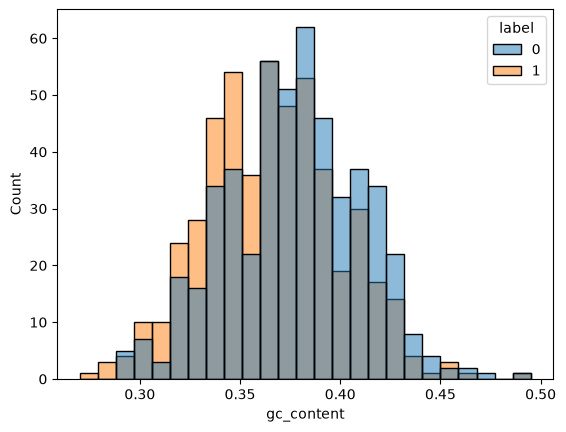

In [5]:
# Q1
avg_gc = df.groupby('label')['gc_content'].mean()
print(f"average GC by expression: {avg_gc}\n")

#Q2
fraction_high_tata = df.groupby('label')['tata_present'].mean()
print(f"fraction high expression with tata: {fraction_high_tata}\n")

#Q3
sns.histplot(data=df, x = "gc_content", hue = "label")

# 1.5 Feature Engineering: One-Hot Encoding

In [15]:
import numpy as np

def one_hot_encode(seq):
    mapping = {'A': 0, 'T': 1, 'G': 2, 'C': 3}
    matrix = np.zeros((len(seq), 4))

    # enumerate is needed to get the index from the string
    for index, base in enumerate(seq):
        # check regular base. If not, all zeros stay
        if base in mapping: 
            matrix[index, mapping.get(base)] = 1
    
    return matrix

### testing
#encoded = one_hot_encode("ANTGC")
#print(encoded)
#print(f"Shape: {encoded.shape}")

result = np.stack(df['sequence'].apply(one_hot_encode))
print(f"result.shape: {result.shape}")
result = result.reshape(1000, -1)
print(f"size of final result: {result.shape}")

#save files from this module
np.savetxt("data/promoters.1hot.csv", result, delimiter=",")
df.to_csv("data/promoter_by_expression.csv", index=False)

result.shape: (1000, 200, 4)
size of final result: (1000, 800)
